# Machine Learning with Spark

In [ ]:
# importing the necessary libraries
from pyspark import SparkContext
from pyspark.sql import SparkSession
# sc = SparkContext('local[*]')
# spark = SparkSession(sc)

To create a SparkSession:

In [ ]:
spark = SparkSession.builder.master('local').getOrCreate()

Now, we'll load the data into a PySpark DataFrame:

In [ ]:
## reading in pyspark df
spark_df = spark.read.csv('./data/machine_learning_with_spark/forestfires.csv', header='true', inferSchema='true')

## observing the datatype of df
type(spark_df)

You'll notice that some of the methods are extremely similar or the same as those found within Pandas.

In [ ]:
spark_df.head()

In [ ]:
spark_df.columns

Selecting multiple columns is similar as well:

In [ ]:
spark_df[['month','day','rain']]

But selecting one column is different. If you want to maintain the methods of a spark DataFrame, you should use the `.select()` method. If you want to just select the column, you can use the same method you would use in pandas (this is primarily what you would use if you're attempting to create a boolean mask).

In [ ]:
d = spark_df.select('rain')

In [ ]:
spark_df['rain']

Let's take a look at all of our data types in this dataframe

In [ ]:
spark_df.dtypes

## Aggregations with our DataFrame

Let's investigate to see if there is any correlation between what month it is and the area of fire:

In [ ]:
spark_df_months = spark_df.groupBy('month').agg({'area': 'mean'})
spark_df_months

Notice how the grouped DataFrame is not returned when you call the aggregation method. Remember, this is still Spark! The transformations and actions are kept separate so that it is easier to manage large quantities of data. You can perform the transformation by calling `.collect()`:

In [ ]:
spark_df_months.collect()

As you can see, there seem to be larger area fires during what would be considered the summer months in Portugal. On your own, practice more aggregations and manipulations that you might be able to perform on this dataset.

## Boolean Masking 

Boolean masking also works with PySpark DataFrames just like Pandas DataFrames, the only difference being that the `.filter()` method is used in PySpark. To try this out, let's compare the amount of fire in those areas with absolutely no rain to those areas that had rain.

In [ ]:
no_rain = spark_df.filter(spark_df['rain'] == 0.0)
some_rain = spark_df.filter(spark_df['rain'] > 0.0)

Now, to perform calculations to find the mean of a column, we'll have to import functions from `pyspark.sql`. As always, to read more about them, check out the [documentation](https://spark.apache.org/docs/latest/api/python/pyspark.sql.html#module-pyspark.sql.functions).

In [ ]:
from pyspark.sql.functions import mean

print('no rain fire area: ', no_rain.select(mean('area')).show(),'\n')

print('some rain fire area: ', some_rain.select(mean('area')).show(),'\n')

Yes there's definitely something there! Unsurprisingly, rain plays in a big factor in the spread of wildfire.

Let's obtain data from only the summer months in Portugal (June, July, and August). We can also do the same for the winter months in Portugal (December, January, February).

In [ ]:
summer_months = spark_df.filter(spark_df['month'].isin(['jun','jul','aug']))
winter_months = spark_df.filter(spark_df['month'].isin(['dec','jan','feb']))

print('summer months fire area', summer_months.select(mean('area')).show())
print('winter months fire areas', winter_months.select(mean('area')).show())

## Machine Learning

Now that we've performed some data manipulation and aggregation, lets get to the really cool stuff, machine learning! PySpark states that they've used scikit-learn as an inspiration for their implementation of a machine learning library. As a result, many of the methods and functionalities look similar, but there are some crucial distinctions. There are three main concepts found within the ML library:

`Transformer`: An algorithm that transforms one PySpark DataFrame into another DataFrame. 

`Estimator`: An algorithm that can be fit onto a PySpark DataFrame that can then be used as a Transformer. 

`Pipeline`: A pipeline very similar to an `sklearn` pipeline that chains together different actions.

The reasoning behind this separation of the fitting and transforming step is because Spark is lazily evaluated, so the 'fitting' of a model does not actually take place until the Transformation action is called. Let's examine what this actually looks like by performing a regression on the Forest Fire dataset. To start off with, we'll import the necessary libraries for our tasks.

In [ ]:
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml import feature
from pyspark.ml.feature import StringIndexer, VectorAssembler, OneHotEncoderEstimator

Looking at our data, one can see that all the categories are numerical except for day and month. We saw some correlation between the month and area burned in a fire, so we will include that in our model. The day of the week, however, is highly unlikely to have any effect on fire, so we will drop it from the DataFrame.

In [ ]:
fire_df = spark_df.drop('day')
fire_df.head()

In order for us to run our model, we need to turn the months variable into a dummy variable. In `ml` this is a 2-step process that first requires turning the categorical variable into a numerical index (`StringIndexer`). Only after the variable is an integer can PySpark create dummy variable columns related to each category (`OneHotEncoderEstimator`). Your key parameters when using these `ml` estimators are: `inputCol` (the column you want to change) and `outputCol` (where you will store the changed column). Here it is in action:

In [ ]:
si = StringIndexer(inputCol='month', outputCol='month_num')
model = si.fit(fire_df)
new_df = model.transform(fire_df)

Note the small, but critical distinction between `sklearn`'s implementation of a transformer and PySpark's implementation. `sklearn` is more object oriented and Spark is more functional oriented.

In [ ]:
## this is an estimator (an untrained transformer)
type(si)

In [ ]:
## this is a transformer (a trained transformer)
type(model)

In [ ]:
model.labels

In [ ]:
new_df.head(4)

As you can see, we have created a new column called `'month_num'` that represents the month by a number. Now that we have performed this step, we can use Spark's version of `OneHotEncoder()` - `OneHotEncoderEstimator()`. Let's make sure we have an accurate representation of the months.

In [ ]:
new_df.select('month_num').distinct().collect()

In [ ]:
## fitting and transforming the OneHotEncoderEstimator
ohe = feature.OneHotEncoderEstimator(inputCols=['month_num'], outputCols=['month_vec'], dropLast=True)
one_hot_encoded = ohe.fit(new_df).transform(new_df)
one_hot_encoded.head()

Great, we now have a OneHotEncoded sparse vector in the `'month_vec'` column! Because Spark is optimized for big data, sparse vectors are used rather than entirely new columns for dummy variables because it is more space efficient. You can see in this first row of the DataFrame:  

`month_vec=SparseVector(11, {2: 1.0})` this indicates that we have a sparse vector of size 11 (because of the parameter `dropLast = True` in `OneHotEncoderEstimator()`) and this particular data point is the 2nd index of our month labels (march, based off the labels in the `model` StringEstimator transformer).  

The final requirement for all machine learning models in PySpark is to put all of the features of your model into one sparse vector. This is once again for efficiency sake. Here, we are doing that with the `VectorAssembler()` estimator.

In [ ]:
features = ['X',
 'Y',
 'FFMC',
 'DMC',
 'DC',
 'ISI',
 'temp',
 'RH',
 'wind',
 'rain',
 'month_vec']

target = 'area'

vector = VectorAssembler(inputCols=features, outputCol='features')
vectorized_df = vector.transform(one_hot_encoded)

In [ ]:
vectorized_df.head()

Great! We now have our data in a format that seems acceptable for the last step. It's time for us to actually fit our model to data! Let's fit a Random Forest Regression model to our data. Although there are still a bunch of other features in the DataFrame, it doesn't matter for the machine learning model API. All that needs to be specified are the names of the features column and the label column.

In [ ]:
## instantiating and fitting the model
rf_model = RandomForestRegressor(featuresCol='features', 
                                 labelCol='area', predictionCol='prediction').fit(vectorized_df)

In [ ]:
rf_model.featureImportances

In [ ]:
## generating predictions
predictions = rf_model.transform(vectorized_df).select('area', 'prediction')
predictions.head(10)

Now we can evaluate how well the model performed using `RegressionEvaluator`.

In [ ]:
from pyspark.ml.evaluation import RegressionEvaluator
evaluator = RegressionEvaluator(predictionCol='prediction', labelCol='area')

In [ ]:
## evaluating r^2
evaluator.evaluate(predictions,{evaluator.metricName: 'r2'})

In [ ]:
## evaluating mean absolute error
evaluator.evaluate(predictions,{evaluator.metricName: 'mae'})

## Putting it all in a Pipeline

We just performed a whole lot of transformations to our data. Let's take a look at all the estimators we used to create this model:

* `StringIndexer()` 
* `OneHotEnconderEstimator()` 
* `VectorAssembler()` 
* `RandomForestRegressor()` 

Once we've fit our model in the Pipeline, we're then going to want to evaluate it to determine how well it performs. We can do this with:

* `RegressionEvaluator()` 

We can streamline all of these transformations to make it much more efficient by chaining them together in a pipeline. The Pipeline object expects a list of the estimators prior set to the parameter `stages`.

In [ ]:
# importing relevant libraries
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit, CrossValidator
from pyspark.ml import Pipeline

In [ ]:
## instantiating all necessary estimator objects

string_indexer = StringIndexer(inputCol='month', outputCol='month_num', handleInvalid='keep')
one_hot_encoder = OneHotEncoderEstimator(inputCols=['month_num'], outputCols=['month_vec'], dropLast=True)
vector_assember = VectorAssembler(inputCols=features, outputCol='features')
random_forest = RandomForestRegressor(featuresCol='features', labelCol='area')
stages = [string_indexer, one_hot_encoder, vector_assember, random_forest]

# instantiating the pipeline with all them estimator objects
pipeline = Pipeline(stages=stages)

### Cross-validation 

You might have missed a critical step in the random forest regression above; we did not cross validate or perform a train/test split! Now we're going to fix that by performing cross-validation and also testing out multiple different combinations of parameters in PySpark's `GridSearch()` equivalent. To begin with, we will create a parameter grid that contains the different parameters we want to use in our model.

In [ ]:
# creating parameter grid

params = ParamGridBuilder()\
          .addGrid(random_forest.maxDepth, [5, 10, 15])\ 
          .addGrid(random_forest.numTrees, [20 ,50, 100])\ 
          .build()

Let's take a look at the params variable we just built.

In [ ]:
print('total combinations of parameters: ', len(params))

params[0]

Now it's time to combine all the steps we've created to work in a single line of code with the `CrossValidator()` estimator.

In [ ]:
## instantiating the evaluator by which we will measure our model's performance
reg_evaluator = RegressionEvaluator(predictionCol='prediction', labelCol='area', metricName = 'mae')

## instantiating crossvalidator estimator
cv = CrossValidator(estimator=pipeline, estimatorParamMaps=params, evaluator=reg_evaluator, parallelism=4)

In [ ]:
## fitting crossvalidator
cross_validated_model = cv.fit(fire_df)

Now, let's see how well the model performed! Let's take a look at the average performance for each one of our 9 models. It looks like the optimal performance is an MAE around 23. Note that this is worse than our original model, but that's because our original model had substantial data leakage. We didn't do a train-test split!

In [ ]:
cross_validated_model.avgMetrics

Now, let's take a look at the optimal parameters of our best performing model. The `cross_validated_model` variable is now saved as the best performing model from the grid search just performed. Let's look to see how well the predictions performed. As you can see, this dataset has a large number of areas of "0.0" burned. Perhaps, it would be better to investigate this problem as a classification task.

In [ ]:
predictions = cross_validated_model.transform(spark_df)
predictions.select('prediction', 'area').show(300)

Now let's go ahead and take a look at the feature importances of our random forest model. In order to do this, we need to unroll our pipeline to access the random forest model. Let's start by first checking out the `.bestModel` attribute of our `cross_validated_model`.

In [ ]:
type(cross_validated_model.bestModel)

`ml` is treating the entire pipeline as the best performing model, so we need to go deeper into the pipeline to access the random forest model within it. Previously, we put the random forest model as the final "stage" in the stages variable list. Let's look at the `.stages` attribute of the `.bestModel`.

In [ ]:
cross_validated_model.bestModel.stages

Perfect! There's the RandomForestRegressionModel, represented by the last item in the stages list. Now, we should be able to access all the attributes of the random forest regressor.

In [ ]:
optimal_rf_model = cross_validated_model.bestModel.stages[3]

In [ ]:
optimal_rf_model.featureImportances

In [ ]:
optimal_rf_model.getNumTrees

---

To begin with create a SparkSession and import the `'data/machine_learning_with_spark_lab/credit_card_default.csv'` file  into a PySpark DataFrame.

In [ ]:
# import necessary libraries
from pyspark import SparkContext
from pyspark.sql import SparkSession
# initialize Spark Session


# read in csv to a spark dataframe
spark_df = None

Check the datatypes to ensure that all columns are the datatype you expect.

Check to see how many missing values are in the dataset. This will require using the `.filter()` , `.isNull()`, and `.count()` methods.

In [ ]:
for col in spark_df.columns:
    # your code here

column ID 0
column LIMIT_BAL 0
column SEX 0
column EDUCATION 0
column MARRIAGE 0
column AGE 0
column PAY_0 0
column PAY_2 0
column PAY_3 0
column PAY_4 0
column PAY_5 0
column PAY_6 0
column BILL_AMT1 0
column BILL_AMT2 0
column BILL_AMT3 0
column BILL_AMT4 0
column BILL_AMT5 0
column BILL_AMT6 0
column PAY_AMT1 0
column PAY_AMT2 0
column PAY_AMT3 0
column PAY_AMT4 0
column PAY_AMT5 0
column PAY_AMT6 0
column default 0


Now, determine how many categories there are in each of the categorical columns.

In [ ]:
for column, data_type in spark_df.dtypes:
   # your code here

Feature  SEX  has:  [Row(SEX='Female'), Row(SEX='Male')]
Feature  EDUCATION  has:  [Row(EDUCATION='High School'), Row(EDUCATION='0'), Row(EDUCATION='5'), Row(EDUCATION='6'), Row(EDUCATION='Other'), Row(EDUCATION='Graduate'), Row(EDUCATION='College')]
Feature  MARRIAGE  has:  [Row(MARRIAGE='0'), Row(MARRIAGE='Other'), Row(MARRIAGE='Married'), Row(MARRIAGE='Single')]


Interesting... it looks like we have some extraneous values in each of our categories. Let's look at some visualizations of each of these to determine just how many of them there are. Create bar plots of the variables `'EDUCATION'` and `'MARRIAGE'` to see how many of the undefined values there are. After doing so, come up with a strategy for accounting for the extra values.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt



## plotting the categories for education


<Figure size 640x480 with 1 Axes>

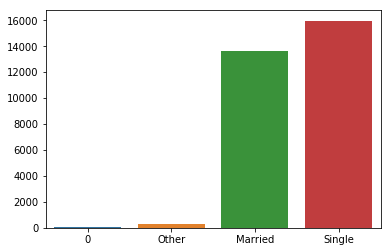

In [ ]:
## plotting the categories for marriage


It looks like there are barely any of the 0 and 5 categories. We can go ahead and throw them into the "Other" category since it's already operating as a catchall here. Similarly, the category "0" looks small, so let's throw it in with the "Other" values. You can do this by using a method called `.when()` from PySpark in conjunction with `.withColumn()` and `.otherwise()`.

In [ ]:
from pyspark.sql.functions import when

## changing the values in the education column

## changing the values in the marriage column

spark_df_done = None

In [ ]:
spark_df_done.head()

Row(ID=2, LIMIT_BAL=120000.0, SEX='Female', EDUCATION='College', MARRIAGE='Single', AGE=26, PAY_0=-1, PAY_2=2, PAY_3=0, PAY_4=0, PAY_5=0, PAY_6=2, BILL_AMT1=2682.0, BILL_AMT2=1725.0, BILL_AMT3=2682.0, BILL_AMT4=3272.0, BILL_AMT5=3455.0, BILL_AMT6=3261.0, PAY_AMT1=0.0, PAY_AMT2=1000.0, PAY_AMT3=1000.0, PAY_AMT4=1000.0, PAY_AMT5=0.0, PAY_AMT6=2000.0, default=1)

Now let's take a look at all the values contained in the categorical columns of the DataFrame:

In [ ]:
for column, data_type in spark_df_done.dtypes:
    # your code here

Feature  SEX  has:  [Row(SEX='Female'), Row(SEX='Male')]
Feature  EDUCATION  has:  [Row(EDUCATION='High School'), Row(EDUCATION='Other'), Row(EDUCATION='Graduate'), Row(EDUCATION='College')]
Feature  MARRIAGE  has:  [Row(MARRIAGE='Other'), Row(MARRIAGE='Married'), Row(MARRIAGE='Single')]


Much better. Now, let's do a little more investigation into our target variable before diving into the machine learning aspect of this project.

##  EDA

Let's first look at the overall distribution of class balance of the default and not default labels. Create a barplot to compare the number of defaults vs. non-defaults. This will require using `.groupBy()` as well as an aggregation method.

Let's also visualize the difference in default rate between males and females in this dataset.

In [ ]:
# perform a groupby for default and sex


[Row(default=1, SEX='Female', count=3762),
 Row(default=0, SEX='Male', count=9015),
 Row(default=1, SEX='Male', count=2873),
 Row(default=0, SEX='Female', count=14349)]

[Text(0,0,'No Default (0)'), Text(0,0,'Default (1)')]

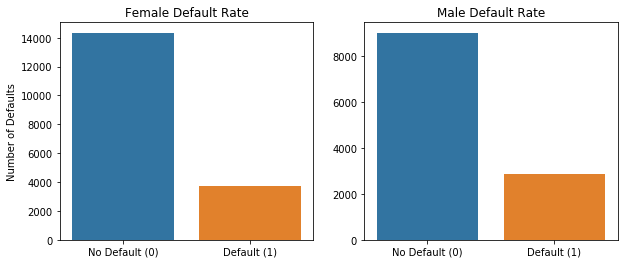

In [ ]:
# make barplot for female and male default v no default rate

It looks like males have an ever so slightly higher default rate than females.

## Onto the Machine Learning!

Now, it's time to fit the data to the PySpark machine learning model pipeline. You will need:

* 3 StringIndexers (for each categorical feature)
* A OneHotEncoderEstimator (to encode the newly indexed strings into categorical variables)
* A VectorAssembler (to combine all features into one SparseVector)

All of these initialized estimators should be stored in a list.

In [ ]:
# importing the necessary modules


# creating the string indexers


# features to be included in the model 

# adding the categorical features

# putting all of the features into a single vector



[StringIndexer_47acb457ea747325b362, StringIndexer_476d9333661023960df9, StringIndexer_4477bba86fbbf3c44e9b, OneHotEncoderEstimator_41e99280e73030b62fe5, VectorAssembler_45a59eab105a2278079b]


Alright! Now let's see if that worked. Let's investigate how it transforms your dataset. Put all of the stages in a Pipeline and fit it to your data. Look at the features column. Did you obtain the number of features you expected?

In [ ]:
from pyspark.ml.pipeline import Pipeline


# 17 numerical features and 6 categorical ones (the argument dropLast = True makes us have Sex, 3 Edu variables and 2 marriage)

Row(features=SparseVector(23, {0: 120000.0, 1: 26.0, 2: -1.0, 3: 2.0, 7: 2.0, 8: 2682.0, 9: 1725.0, 10: 2682.0, 11: 3272.0, 12: 3455.0, 13: 3261.0, 14: 1.0, 18: 1.0, 20: 1.0}))

## Fitting Machine Learning Models
That looks good! Now let's go ahead and fit data to different machine learning models. To evaluate these models, you should use the `BinaryClassificationEvaluator`. Below is an import of all the classes and libraries you'll need in the remainder of this lab.

In [ ]:
from pyspark.ml.classification import GBTClassifier, DecisionTreeClassifier, LogisticRegression, RandomForestClassifier
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator, TrainValidationSplit
from pyspark.ml.evaluation import BinaryClassificationEvaluator
import numpy as np

### Logistic Regression

First, we'll try with a simple Logistic Regression Model:

* instantiate a logistic regression model
* add it to the stages list
* instantiate a new Pipeline estimator (not fit) with all of the stages
* instantiate an `BinaryClassificationEvaluator`
* create parameters to gridsearch through using `ParamGridBuilder`
* Instantiate and fit a `CrossValidator`

In [ ]:
# your code here


Determine how well your model performed by looking at the evaluator metrics. If you tried multiple parameters, which performed best?

In [ ]:
# print out the AUC of your best model as well as the parameters of your best model


0.7183252301096683 AUC
best parameters :  {Param(parent='LogisticRegression_4e12b7861559618c2aa6', name='regParam', doc='regularization parameter (>= 0).'): 0.0, Param(parent='LogisticRegression_4e12b7861559618c2aa6', name='standardization', doc='whether to standardize the training features before fitting the model.'): True}


#### Now try this again with other classifiers. Try and create a function that will allow you to easily test different models with different parameters. This function is optional, but it should allow for your code to be far more D.R.Y. The function should return the fitted cross-validated model as well as print out the performance metrics of the best performing model and the best parameters.

In [ ]:
# create function to cross validate models with different parameters



Train a Random Forest classifier and determine the best performing model with the best parameters. This might take a while! Be smart about how you use parallelization here.

In [ ]:
# code to train Random Forest Classifier
# ⏰ This cell may take a long time to run


best performing model:  0.7826543113276045 AUC
best parameters:  {Param(parent='RandomForestClassifier_4ddb8a67eee4da94132a', name='maxDepth', doc='Maximum depth of the tree. (>= 0) E.g., depth 0 means 1 leaf node; depth 1 means 1 internal node + 2 leaf nodes.'): 10, Param(parent='RandomForestClassifier_4ddb8a67eee4da94132a', name='numTrees', doc='Number of trees to train (>= 1).'): 200}


Now train a Gradient Boosting Classifier. **This might take a very long time depending on the number of parameters you are training**

In [ ]:
# code to train Gradient Boosting Classifier
# ⏰ This cell may take a long time to run


best performing model:  0.7798494380533647 AUC
best parameters:  {Param(parent='GBTClassifier_42569733d04d7a375612', name='maxDepth', doc='Maximum depth of the tree. (>= 0) E.g., depth 0 means 1 leaf node; depth 1 means 1 internal node + 2 leaf nodes.'): 5, Param(parent='GBTClassifier_42569733d04d7a375612', name='maxIter', doc='max number of iterations (>= 0).'): 50}


It looks like the optimal performing model is the Random Forest Classifier Model because it has the highest AUC!

## Level Up (Optional)

* Create ROC curves for each of these models
* Try the multi-layer perceptron classifier algorithm. You will soon learn about what this means in the neural network section!